# Data Preparation on Respiratory Virus Dashboard Dataset

In [1]:
import pandas as pd

from src.compare import compare_transformations, compare_skewness, compare_distributions
from src.enums import rv_keys, prefixes, files
from src.transform import Transformation, transform

rv = pd.read_csv(files['data/03-26-respiratory-virus-dashboard-pre-narrowed.csv'])

## Clean up respiratory virus data

Remove mostly null and non-representative columns from respiratory virus data.

In [2]:
rv_cleaned = rv.copy()
rv_cleaned = rv.drop([
    rv_keys['FLU_A_TESTS'], # Dropped because 3/4 of the data is missing.
    rv_keys['FLU_B_TESTS'], # Dropped because 3/4 of the data is missing.
    rv_keys['COV_ADM'], # Although only 1/5 of this data is missing, the corresponding columns in other virus categories have much higher rates of null values, so we are dropping them together to maintain consistency.
    rv_keys['FLU_ADM'], # Dropped because half of the data is missing.
    rv_keys['RSV_ADM'], # Dropped because half of the data is missing.
    rv_keys['COV_ADM_RATE'], # Although only 1/5 of this data is missing, the corresponding columns in other virus categories have much higher rates of null values, so we are dropping them together to maintain consistency.
    rv_keys['FLU_ADM_RATE'], # Dropped because half of the data is missing.
    rv_keys['RSV_ADM_RATE'], # Dropped because half of the data is missing.
    rv_keys['COV_ADM_LEVEL'], # Although only 1/5 of this data is missing, the corresponding columns in other virus categories have much higher rates of null values, so we are dropping them together to maintain consistency.
    rv_keys['FLU_ADM_LEVEL'], # Dropped because half of the data is missing.
    rv_keys['RSV_ADM_LEVEL'], # Dropped because half of the data is missing.
    rv_keys['POP'], # Dropped because 1/5 of this data is missing and there is very little variance.
], axis=1)

rv_columns_with_null = []

for key in rv_cleaned.columns.tolist():
    null_count = rv_cleaned[key].isna().sum()
    if null_count > 0:
        rv_columns_with_null.append(key)

print(f"Columns with null values: {len(rv_columns_with_null)}")
rv_cleaned.head(3)

Columns with null values: 0


,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,COV_POSITIVES,COV_TOTAL_TESTS,COV_TP,COV_TP_LEVEL,FLU_POSITIVES,FLU_TOTAL_TESTS,...,RSV_TOTAL_TESTS,RSV_TP,RSV_TP_LEVEL,TOTAL_DEATHS,COV_DEATHS,FLU_DEATHS,RSV_DEATHS,COV_DEATHS_PER,FLU_DEATHS_PER,RSV_DEATHS_PER
0,2023/2024,07/08/2023,27,2023,1799,40924,4.395953,Low,69,1545,...,1550,0.516129,Very Low,1068.0,22,1,0,2.059925,0.093633,0.000000
1,2023/2024,07/15/2023,28,2023,2050,41354,4.957199,Low,92,1670,...,1641,0.670323,Very Low,1013.0,16,0,0,1.579467,0.000000,0.000000
2,2023/2024,07/22/2023,29,2023,2226,41390,5.378111,Low,46,1531,...,1518,0.922266,Very Low,1042.0,17,0,1,1.631478,0.000000,0.095969


## Stabilize respiratory virus data

Apply transformation to skewed columns to stabilize variance and make the data more normally distributed.

### Compare skewness across different transformations

In [3]:
compare_transformations(rv_cleaned)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
SEASON,N/A,N/A,N/A,N/A,N/A
WEEKENDING,N/A,N/A,N/A,N/A,N/A
MMWR_WEEK,-0.2,-0.69,-1.25,-0.91,-0.32
MMWR_YEAR,-0.05,-0.05,-0.05,-0.05,-0.03
COV_POSITIVES,0.84,0.31,-0.43,0.09,-0.07
COV_TOTAL_TESTS,0.03,-0.12,-0.27,-0.17,-0.1
COV_TP,0.65,0.19,-0.06,0.02,-0.02
COV_TP_LEVEL,N/A,N/A,N/A,N/A,N/A
FLU_POSITIVES,2.42,1.2,0.2,0.83,0.05
FLU_TOTAL_TESTS,0.58,-0.05,-0.97,-0.31,-0.06


### Transform skewed features

In [4]:
transformations = {
    rv_keys['COV_POSITIVES']: Transformation.SQRT,
    rv_keys['COV_TP']: Transformation.SQRT,
    rv_keys['FLU_TOTAL_TESTS']: Transformation.SQRT,
    rv_keys['RSV_TOTAL_TESTS']: Transformation.SQRT,
    rv_keys['COV_DEATHS']: Transformation.SQRT,
    rv_keys['COV_DEATHS_PER']: Transformation.SQRT,

    rv_keys['FLU_POSITIVES']: Transformation.LOG1P,
    rv_keys['FLU_TP']: Transformation.LOG1P,
    rv_keys['RSV_POSITIVES']: Transformation.LOG1P,
    rv_keys['RSV_TP']: Transformation.LOG1P,

    rv_keys['TOTAL_DEATHS']: Transformation.YEO_JOHNSON,
    rv_keys['FLU_DEATHS']: Transformation.YEO_JOHNSON,
    rv_keys['RSV_DEATHS']: Transformation.YEO_JOHNSON,
    rv_keys['FLU_DEATHS_PER']: Transformation.YEO_JOHNSON,
    rv_keys['RSV_DEATHS_PER']: Transformation.YEO_JOHNSON,
}

rv_transformed = transform(
    rv_cleaned,
    transformations,
    prefixes['03_30_data_preparation_respiratory_virus_dashboard_']
)

### Skewness comparison

In [5]:
compare_skewness(rv_cleaned, rv_transformed, transformations)

,Changes,Skewness (Original),Skewness (Target)
COV_POSITIVES,sqrt,0.84,0.31
COV_TP,sqrt,0.65,0.19
FLU_TOTAL_TESTS,sqrt,0.58,-0.05
RSV_TOTAL_TESTS,sqrt,0.52,-0.0
COV_DEATHS,sqrt,0.74,-0.06
COV_DEATHS_PER,sqrt,0.59,-0.12
FLU_POSITIVES,log1p,2.42,0.2
FLU_TP,log1p,1.41,0.33
RSV_POSITIVES,log1p,1.41,0.01
RSV_TP,log1p,1.74,0.48


### Distribution comparison

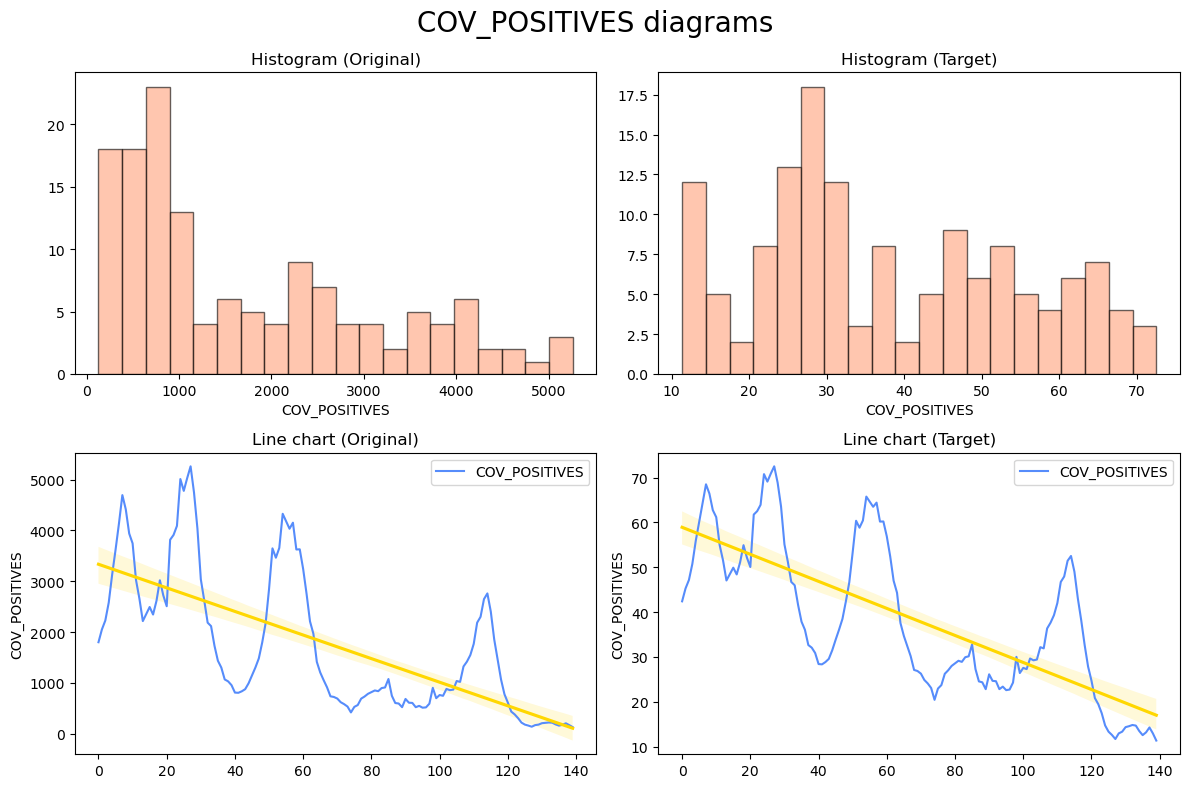

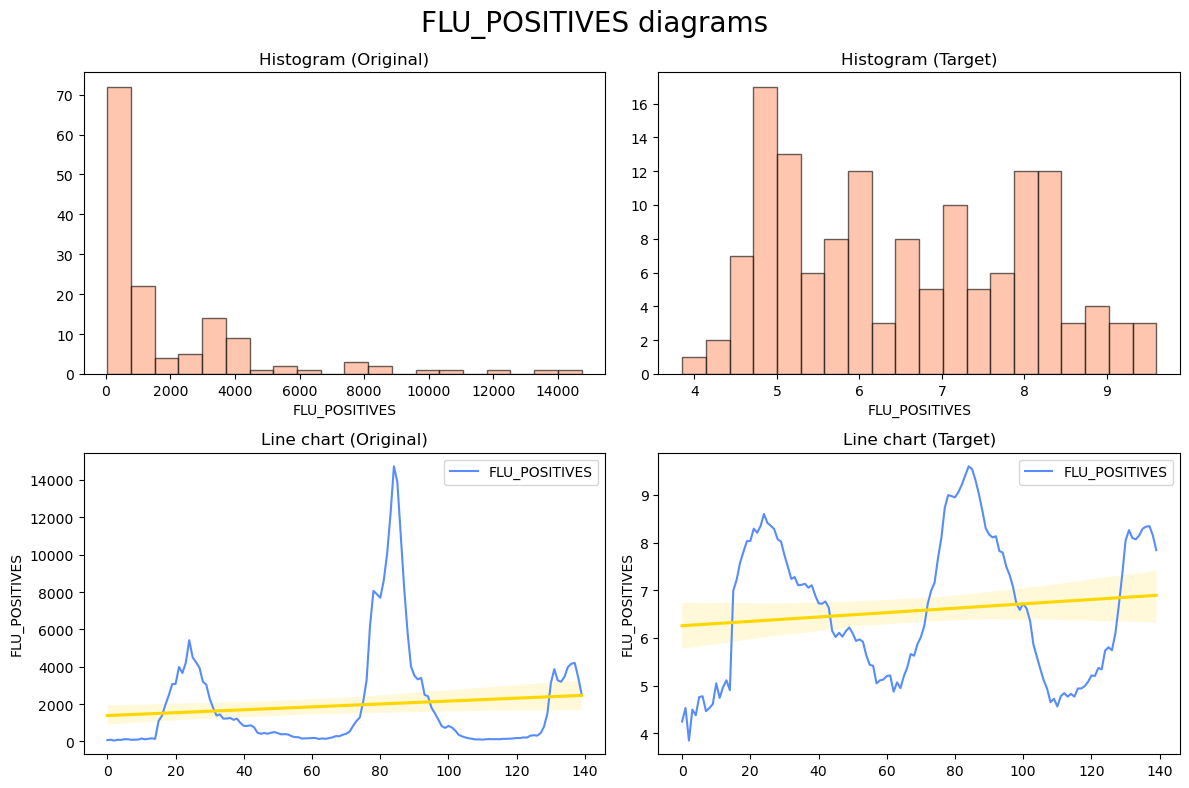

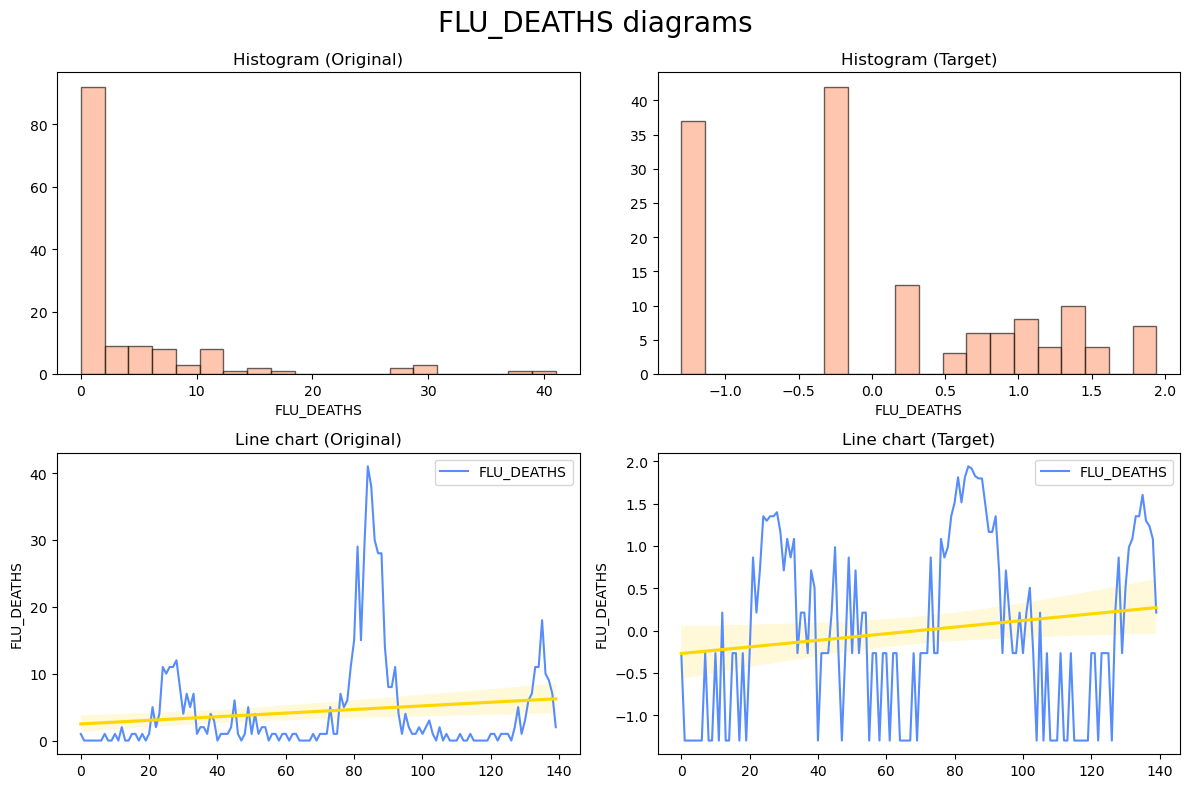

In [6]:
compare_distributions(
    rv_cleaned,
    rv_transformed,
    [
        rv_keys['COV_POSITIVES'], # square root transformation.
        rv_keys['FLU_POSITIVES'], # log transformation.
        rv_keys['FLU_DEATHS'] # Yeo-Johnson transformation.
    ]
)

## Checkpoint

In [7]:
rv_checkpoint = rv_transformed.copy()
rv_checkpoint = rv_checkpoint.sort_values(by=[rv_keys['MMWR_YEAR'], rv_keys['MMWR_WEEK']])
rv_checkpoint.to_csv(files['data/04-01-respiratory-virus-dashboard-cleaned-transformed.csv'], index=False)